# PyEncode — Paper Experiments
Reproduces all examples, figures, and gate count table from the paper.

## 1. Imports and Configuration

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from qiskit import transpile, QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import StatePreparation

from pyencode import (
    encode,
    SPARSE, STEP, SQUARE, FOURIER, WALSH, GEOMETRIC, LCU,
    EncodingInfo, VectorType,
)
from pyencode.config import BASIS_GATES, OPTIMIZATION_LEVEL, DECOMPOSE_REPS

N = 64
k = np.arange(N)


## 2. Helper Functions

In [3]:
def plot_vector(f, title, smooth=False):
    """Plot a vector with bar or smooth style."""
    fig, ax = plt.subplots(figsize=(6, 2.5))
    x = np.arange(len(f))
    if smooth:
        ax.plot(x, f, "steelblue", lw=1.5)
        ax.fill_between(x, 0, f, alpha=0.25)
    else:
        ax.bar(x, f, color="steelblue", width=0.7)
    ax.set_title(title)
    ax.set_xlabel("index $i$")
    plt.tight_layout(); plt.show()

def verify_circuit(circuit, info, label=""):
    """Simulate and verify circuit matches expected statevector.
    Prints raw gate count, transpiled 1q/2q counts, and complexity.
    """
    sv = np.abs(np.array(Statevector(circuit)))
    _1q = info.gate_count_1q if info.gate_count_1q is not None else "n/a"
    _2q = info.gate_count_2q if info.gate_count_2q is not None else "n/a"
    print(f"{label}: raw={info.gate_count}  1q={_1q}  2q={_2q}  [{info.complexity}]")
    return sv

def qiskit_gate_counts(f):
    """Qiskit StatePreparation gate counts (total, 1q, 2q) on the same vector."""
    norm = np.linalg.norm(f)
    if norm < 1e-14:
        return 0, 0, 0
    sv = (f / norm).astype(complex)
    qc = QuantumCircuit(int(round(np.log2(len(f)))))
    qc.append(StatePreparation(sv), range(qc.num_qubits))
    t = transpile(qc.decompose(reps=DECOMPOSE_REPS), basis_gates=BASIS_GATES,
                  optimization_level=OPTIMIZATION_LEVEL)
    ops = t.count_ops()
    cx   = ops.get("cx", 0)
    u    = ops.get("u",  0)
    total = sum(ops.values())
    return total, u, cx

# Keep old name as alias for backward-compat with other cells
def qiskit_gate_count(f):
    total, _, _ = qiskit_gate_counts(f)
    return total


---
## 3. All Vector Types
### 3.1 SPARSE — Gleinig-Hoefler $\mathcal{O}(sm)$

PyEncode  v1.0.0
  Vector type : SPARSE
  N           : 64  (m = 6 qubits)
  Gate count  : 3
  Complexity  : O(s·m)
  Validated   : no
  Gates 1q/2q : 3 / 0
  Depth       : 1
  Success prob: 1.0
  Parameters  : {'loads': [{'k': 19, 'P': 1.0}]}
  Circuit code: 272 chars (info.circuit_code)


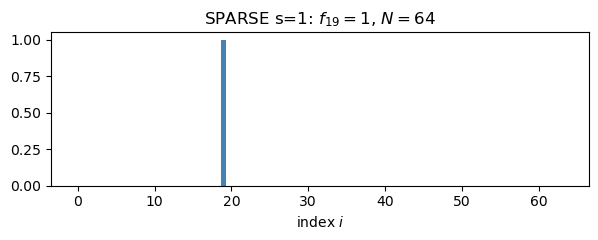

SPARSE s=1: raw=3  1q=3  2q=0  [O(s·m)]


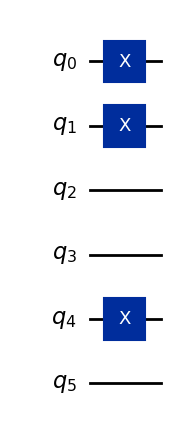

In [4]:
# s=1: motivating example from paper (index 19, N=64)
circuit, info = encode(SPARSE([(19, 1.0)]), N=N)
print(info)

f = np.zeros(N); f[19] = 1.0
plot_vector(f, r"SPARSE s=1: $f_{19}=1$, $N=64$")
verify_circuit(circuit, info, "SPARSE s=1")
circuit.draw("mpl")


PyEncode  v1.0.0
  Vector type : SPARSE
  N           : 64  (m = 6 qubits)
  Gate count  : 6
  Complexity  : O(s·m)
  Validated   : no
  Gates 1q/2q : 4 / 2
  Depth       : 3
  Success prob: 1.0
  Parameters  : {'loads': [{'k': 10, 'P': 3.0}, {'k': 50, 'P': 4.0}]}
  Circuit code: 467 chars (info.circuit_code)


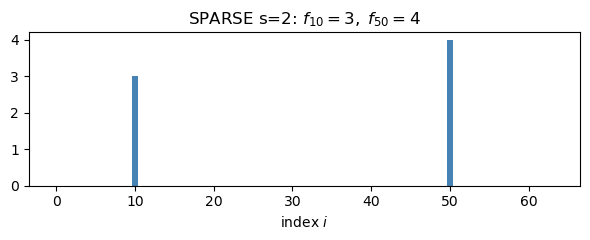

SPARSE s=2: raw=6  1q=4  2q=2  [O(s·m)]


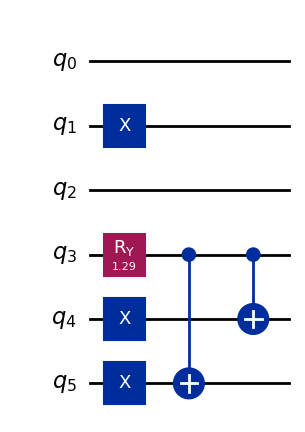

In [5]:
# s=2: two point masses
circuit, info = encode(SPARSE([(10, 3.0), (50, 4.0)]), N=N)
print(info)

f = np.zeros(N); f[10] = 3.0; f[50] = 4.0
plot_vector(f, r"SPARSE s=2: $f_{10}=3,\;f_{50}=4$")
verify_circuit(circuit, info, "SPARSE s=2")
circuit.draw("mpl")


### 3.2 STEP — Shukla & Vedula $\mathcal{O}(m)$

PyEncode  v1.0.0
  Vector type : STEP
  N           : 64  (m = 6 qubits)
  Gate count  : 2
  Complexity  : O(m)
  Validated   : no
  Gates 1q/2q : 2 / 0
  Depth       : 1
  Success prob: 1.0
  Parameters  : {'k_s': 4, 'c': 1.0}
  Circuit code: 371 chars (info.circuit_code)


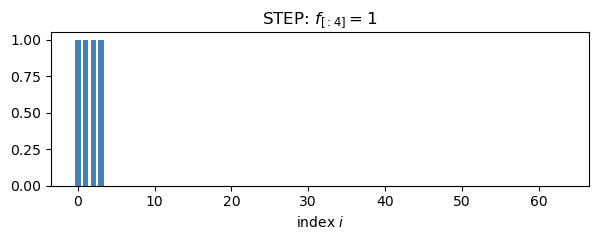

STEP k_s=4: raw=2  1q=2  2q=0  [O(m)]


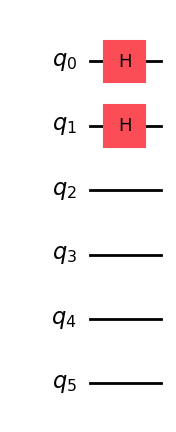

In [6]:
circuit, info = encode(STEP(k_s=4, c=1.0), N=N)
print(info)

f = np.zeros(N); f[:4] = 1.0
plot_vector(f, r"STEP: $f_{[:4]}=1$")
verify_circuit(circuit, info, "STEP k_s=4")
circuit.draw("mpl")


STEP k_s=37: raw=21  1q=16  2q=6  [O(m)]


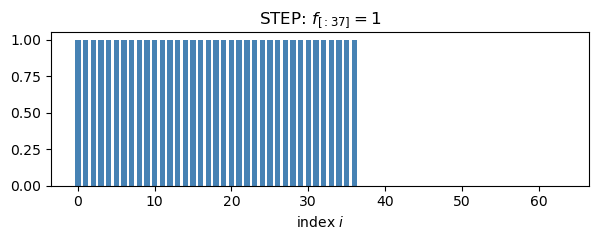

In [7]:
# Non-power-of-2 boundary
circuit, info = encode(STEP(k_s=37, c=1.0), N=N, validate=True)
print(f"STEP k_s=37: raw={info.gate_count}  1q={info.gate_count_1q}  2q={info.gate_count_2q}  [{info.complexity}]")
f = np.zeros(N); f[:37] = 1.0
plot_vector(f, r"STEP: $f_{[:37]}=1$")


### 3.3 SQUARE — general interval $\mathcal{O}(m^2)$

PyEncode  v1.0.0
  Vector type : SQUARE
  N           : 64  (m = 6 qubits)
  Gate count  : 4
  Complexity  : O(m)
  Validated   : no
  Gates 1q/2q : 4 / 0
  Depth       : 1
  Success prob: 1.0
  Parameters  : {'k1': 8, 'k2': 16, 'c': 1.0}
  Circuit code: 559 chars (info.circuit_code)


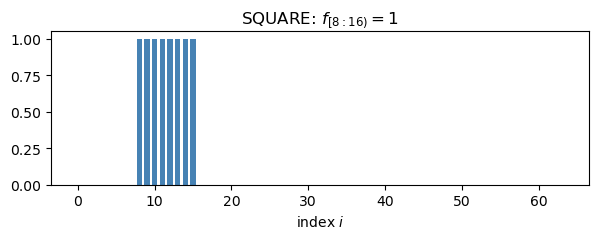

SQUARE [8,16): raw=4  1q=4  2q=0  [O(m)]


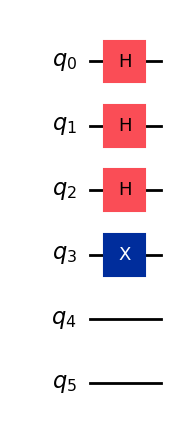

In [8]:
circuit, info = encode(SQUARE(k1=8, k2=16, c=1.0), N=N)
print(info)

f = np.zeros(N); f[8:16] = 1.0
plot_vector(f, r"SQUARE: $f_{[8:16)}=1$")
verify_circuit(circuit, info, "SQUARE [8,16)")
circuit.draw("mpl")


SQUARE [10,50): raw=19  1q=65  2q=38  [O(m²)]


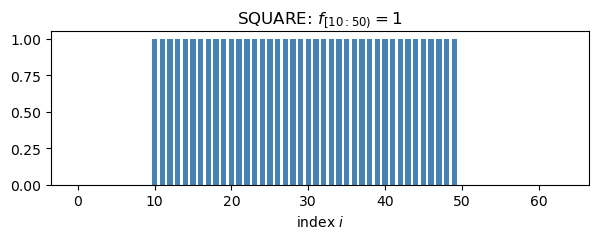

In [9]:
# Non-aligned square (general case)
circuit, info = encode(SQUARE(k1=10, k2=50, c=1.0), N=N, validate=True)
print(f"SQUARE [10,50): raw={info.gate_count}  1q={info.gate_count_1q}  2q={info.gate_count_2q}  [{info.complexity}]")
f = np.zeros(N); f[10:50] = 1.0
plot_vector(f, r"SQUARE: $f_{[10:50)}=1$")


### 3.4 FOURIER — inverse QFT $\mathcal{O}(m^2)$

PyEncode  v1.0.0
  Vector type : FOURIER
  N           : 64  (m = 6 qubits)
  Gate count  : 11
  Complexity  : O(m²)
  Validated   : yes
  Gates 1q/2q : 45 / 33
  Depth       : 41
  Success prob: 1.0
  Vector      : numpy array, shape (64,)
  Parameters  : {'modes': [{'n': 1, 'A': 1.0, 'phi': 0.0}]}
  Circuit code: 3549 chars (info.circuit_code)


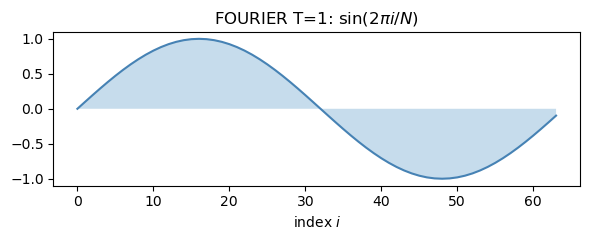

FOURIER T=1 sine: raw=11  1q=45  2q=33  [O(m²)]


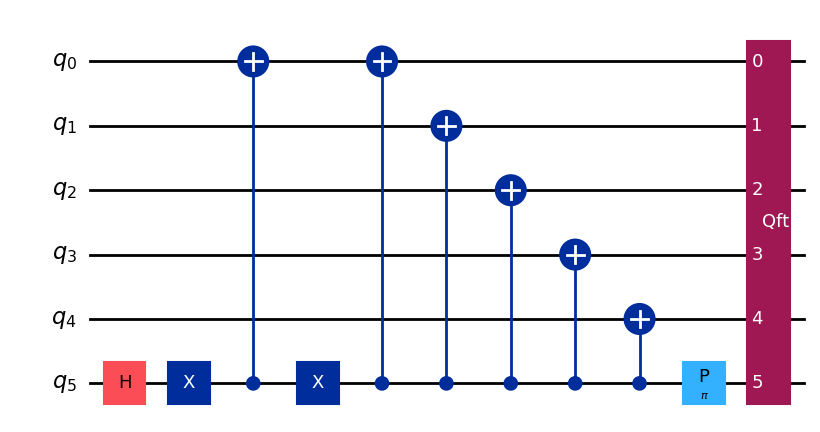

In [10]:
import math
# T=1: sine (phi=0)
circuit, info = encode(FOURIER(modes=[(1, 1.0, 0)]), N=N, validate=True)
print(info)

f = np.sin(2 * np.pi * k / N)
plot_vector(f, r"FOURIER T=1: $\sin(2\pi i/N)$", smooth=True)
verify_circuit(circuit, info, "FOURIER T=1 sine")
circuit.draw("mpl")


FOURIER cosine: raw=11  1q=45  2q=33  [O(m²)]


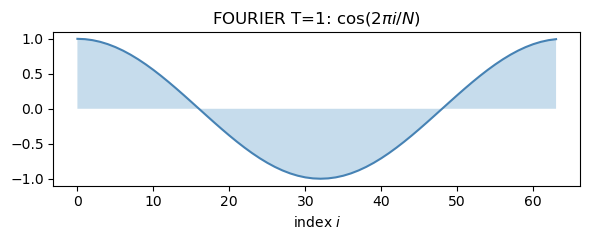

In [11]:
# T=1: cosine (phi=pi/2)
circuit, info = encode(FOURIER(modes=[(1, 1.0, math.pi/2)]), N=N, validate=True)
print(f"FOURIER cosine: raw={info.gate_count}  1q={info.gate_count_1q}  2q={info.gate_count_2q}  [{info.complexity}]")

f = np.cos(2 * np.pi * k / N)
plot_vector(f, r"FOURIER T=1: $\cos(2\pi i/N)$", smooth=True)


PyEncode  v1.0.0
  Vector type : FOURIER
  N           : 64  (m = 6 qubits)
  Gate count  : 13
  Complexity  : O(m²)
  Validated   : no
  Gates 1q/2q : 45 / 35
  Depth       : 44
  Success prob: 1.0
  Parameters  : {'modes': [{'n': 3, 'A': 2.0, 'phi': 0.7853981633974483}]}
  Circuit code: 3649 chars (info.circuit_code)


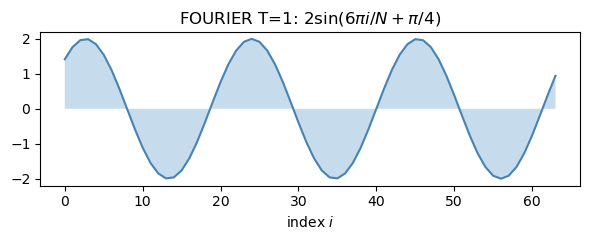

In [12]:
# T=1: n=3, phi=pi/4
circuit, info = encode(FOURIER(modes=[(3, 2.0, math.pi/4)]), N=N)
print(info)

f = 2.0 * np.sin(2 * np.pi * 3 * k / N + math.pi/4)
plot_vector(f, r"FOURIER T=1: $2\sin(6\pi i/N + \pi/4)$", smooth=True)


PyEncode  v1.0.0
  Vector type : FOURIER
  N           : 64  (m = 6 qubits)
  Gate count  : 10
  Complexity  : O(m²)
  Validated   : no
  Gates 1q/2q : 48 / 35
  Depth       : 43
  Success prob: 1.0
  Parameters  : {'modes': [{'n': 1, 'A': 2.0, 'phi': 0.0}, {'n': 3, 'A': 1.0, 'phi': 0.0}]}
  Circuit code: 3730 chars (info.circuit_code)


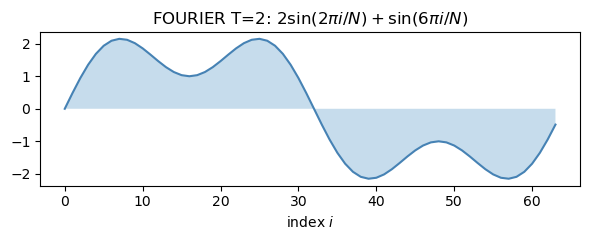

FOURIER T=2: raw=10  1q=48  2q=35  [O(m²)]


array([2.77555756e-17, 3.84468894e-02, 7.47681718e-02, 1.07009880e-01,
       1.33546654e-01, 1.53210629e-01, 1.65381251e-01, 1.70028383e-01,
       1.67705098e-01, 1.59490869e-01, 1.46890133e-01, 1.31695060e-01,
       1.15824399e-01, 1.01152360e-01, 8.93423246e-02, 8.16997453e-02,
       7.90569415e-02, 8.16997453e-02, 8.93423246e-02, 1.01152360e-01,
       1.15824399e-01, 1.31695060e-01, 1.46890133e-01, 1.59490869e-01,
       1.67705098e-01, 1.70028383e-01, 1.65381251e-01, 1.53210629e-01,
       1.33546654e-01, 1.07009880e-01, 7.47681718e-02, 3.84468894e-02,
       1.05709109e-16, 3.84468894e-02, 7.47681718e-02, 1.07009880e-01,
       1.33546654e-01, 1.53210629e-01, 1.65381251e-01, 1.70028383e-01,
       1.67705098e-01, 1.59490869e-01, 1.46890133e-01, 1.31695060e-01,
       1.15824399e-01, 1.01152360e-01, 8.93423246e-02, 8.16997453e-02,
       7.90569415e-02, 8.16997453e-02, 8.93423246e-02, 1.01152360e-01,
       1.15824399e-01, 1.31695060e-01, 1.46890133e-01, 1.59490869e-01,
      

In [13]:
# T=2: multi-mode
circuit, info = encode(FOURIER(modes=[(1, 2.0, 0), (3, 1.0, 0)]), N=N)
print(info)

f = 2.0*np.sin(2*np.pi*k/N) + np.sin(2*np.pi*3*k/N)
plot_vector(f, r"FOURIER T=2: $2\sin(2\pi i/N) + \sin(6\pi i/N)$", smooth=True)
verify_circuit(circuit, info, "FOURIER T=2")


### 3.5 Walsh — $(-1)^{b_k(i)}$ signed uniform superposition — $\mathcal{O}(m)$

PyEncode  v1.0.0
  Vector type : WALSH
  N           : 64  (m = 6 qubits)
  Gate count  : 7
  Complexity  : O(m)
  Validated   : no
  Gates 1q/2q : 6 / 0
  Depth       : 1
  Success prob: 1.0
  Parameters  : {'k': 0, 'c_pos': 1.0, 'c_neg': -1.0}
  Circuit code: 317 chars (info.circuit_code)


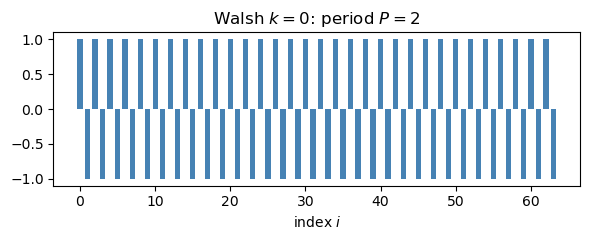

WALSH k=0: raw=7  1q=6  2q=0  [O(m)]


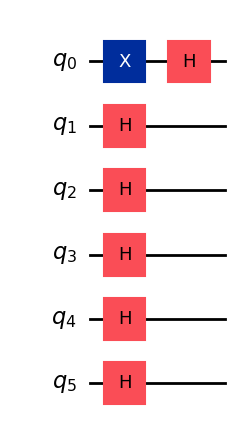

In [14]:
import math
# k=0: period 2 (fastest alternation)
circuit, info = encode(WALSH(k=0), N=N)
print(info)

f = np.array([1 if not ((i >> 0) & 1) else -1 for i in range(N)], dtype=float)
plot_vector(f, "Walsh $k=0$: period $P=2$")
verify_circuit(circuit, info, "WALSH k=0")
circuit.draw("mpl")


PyEncode  v1.0.0
  Vector type : WALSH
  N           : 64  (m = 6 qubits)
  Gate count  : 7
  Complexity  : O(m)
  Validated   : no
  Gates 1q/2q : 6 / 0
  Depth       : 1
  Success prob: 1.0
  Parameters  : {'k': 1, 'c_pos': 1.0, 'c_neg': -1.0}
  Circuit code: 317 chars (info.circuit_code)


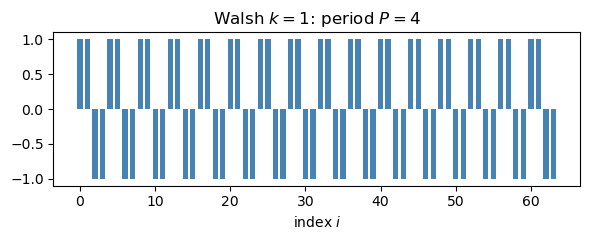

WALSH k=1: raw=7  1q=6  2q=0  [O(m)]


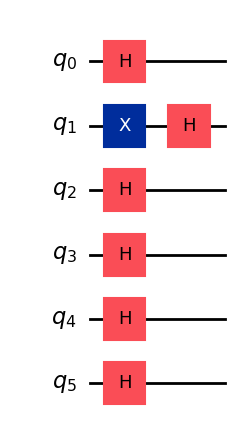

In [15]:
# k=1: period 4
circuit, info = encode(WALSH(k=1), N=N)
print(info)

f = np.array([1 if not ((i >> 1) & 1) else -1 for i in range(N)], dtype=float)
plot_vector(f, "Walsh $k=1$: period $P=4$")
verify_circuit(circuit, info, "WALSH k=1")
circuit.draw("mpl")


In [16]:
# Sweep: gate count vs qubit index k
m_bits = int(round(np.log2(N)))
print(f"m = {m_bits} qubits, N = {N}")
print(f"  {'k':<4} {'period':>8} {'raw':>6} {'1q':>5} {'2q':>5}")
for k_idx in range(m_bits):
    _, info_k = encode(WALSH(k=k_idx), N=N, validate=True)
    print(f"  {k_idx:<4} {2**(k_idx+1):>8} {info_k.gate_count:>6} "
          f"{info_k.gate_count_1q:>5} {info_k.gate_count_2q:>5}")


m = 6 qubits, N = 64
  k      period    raw    1q    2q
  0           2      7     6     0
  1           4      7     6     0
  2           8      7     6     0
  3          16      7     6     0
  4          32      7     6     0
  5          64      7     6     0


### 3.6 GEOMETRIC — product-state exponential decay $\mathcal{O}(m)$

The vector $f_i = c \cdot r^i$ is multiplicatively separable over the bits of $i$,
so the quantum state is a product state prepared by $m$ independent $R_y$ rotations
with **zero two-qubit gates**. See Xie & Ben-Ami (arXiv:2507.20317) for use as
an intermediate construction in Gaussian preparation.

PyEncode  v1.0.0
  Vector type : GEOMETRIC
  N           : 64  (m = 6 qubits)
  Gate count  : 6
  Complexity  : O(m)
  Validated   : yes
  Gates 1q/2q : 5 / 0
  Depth       : 1
  Success prob: 1.0
  Vector      : numpy array, shape (64,)
  Parameters  : {'ratio': 0.5, 'c': 1.0}
  Circuit code: 394 chars (info.circuit_code)


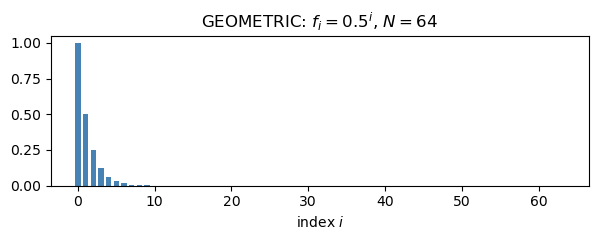


Circuit (6 gates, 0 CX):
       ┌────────────┐  
q_0: ──┤ Ry(0.9273) ├──
      ┌┴────────────┤  
q_1: ─┤ Ry(0.48996) ├──
      ├─────────────┤  
q_2: ─┤ Ry(0.12484) ├──
     ┌┴─────────────┴┐ 
q_3: ┤ Ry(0.0078125) ├─
     ├───────────────┴┐
q_4: ┤ Ry(3.0518e-05) ├
     └───┬───────┬────┘
q_5: ────┤ Ry(0) ├─────
         └───────┘     


In [17]:
# Exponential decay: ratio = 0.5
circuit, info = encode(GEOMETRIC(ratio=0.5), N=N, validate=True)
print(info)

f = 0.5 ** np.arange(N)
plot_vector(f, r"GEOMETRIC: $f_i = 0.5^i$, $N=64$")
print(f"\nCircuit ({info.gate_count} gates, {info.gate_count_2q} CX):")
print(circuit)


In [18]:
# Growth: ratio > 1
circuit, info = encode(GEOMETRIC(ratio=1.05), N=N, validate=True)
print(f"GEOMETRIC ratio=1.05: raw={info.gate_count}, "
      f"1q={info.gate_count_1q}, 2q={info.gate_count_2q}, "
      f"complexity={info.complexity}")

# Sweep gate count vs m
print(f"\nGEOMETRIC gate count vs m:")
for m in [4, 6, 8, 10, 12]:
    Nm = 2 ** m
    _, info_m = encode(GEOMETRIC(ratio=0.95), N=Nm)
    print(f"  m={m:2d}  N={Nm:5d}  gates={info_m.gate_count:3d}  "
          f"1q={info_m.gate_count_1q}  2q={info_m.gate_count_2q}")


GEOMETRIC ratio=1.05: raw=6, 1q=6, 2q=0, complexity=O(m)

GEOMETRIC gate count vs m:
  m= 4  N=   16  gates=  4  1q=4  2q=0
  m= 6  N=   64  gates=  6  1q=6  2q=0
  m= 8  N=  256  gates=  8  1q=8  2q=0
  m=10  N= 1024  gates= 10  1q=9  2q=0
  m=12  N= 4096  gates= 12  1q=9  2q=0


### 3.7 LCU — weighted superposition via Protocol 1

Prepares $|\psi\rangle \propto \sum_j w_j |\hat{f}^{(j)}\rangle$ using $\lceil\log_2 r\rceil$ ancilla qubits.
Success probability $p = \sum_{i,j} \beta_i^2 \beta_j^2 \langle\hat{f}^{(i)}|\hat{f}^{(j)}\rangle$, with $\beta_j = \sqrt{w_j\|f_j\|}/Z$.
Post-select ancilla on $|0\rangle$ to recover the pure target state.

PyEncode  v1.0.0
  Vector type : LCU
  N           : 64  (m = 6 qubits)
  Gate count  : 61
  Complexity  : O(2·m)
  Validated   : no
  Success prob: 0.6250  (post-selection required)
  Parameters  : {'components': ['SQUARE', 'SQUARE'], 'weights': [1.0, 3.0], 'disjoint': True}
  Circuit code: 3025 chars (info.circuit_code)
Success probability: 0.6250
Ancilla qubits: 1


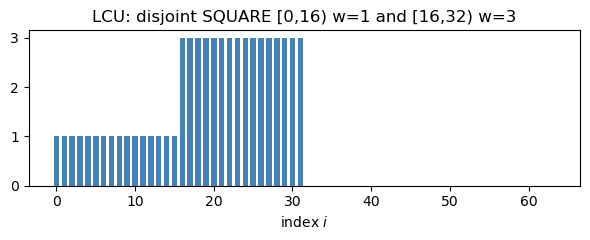

In [19]:
import warnings

# --- Disjoint SQUARE components (MULTI_SQUARE via LCU) ---
# Two disjoint intervals: p determined analytically, no warning issued
circuit, info = encode(
    LCU([(1.0, SQUARE(k1=0,  k2=16, c=1.0)),
         (3.0, SQUARE(k1=16, k2=32, c=1.0))]),
    N=N)
print(info)
print(f'Success probability: {info.success_probability:.4f}')
print(f'Ancilla qubits: {circuit.num_qubits - int(round(np.log2(N)))}')

f = np.zeros(N); f[:16] = 1.0; f[16:32] = 3.0
plot_vector(f, 'LCU: disjoint SQUARE [0,16) w=1 and [16,32) w=3')


PyEncode  v1.0.0
  Vector type : LCU
  N           : 64  (m = 6 qubits)
  Gate count  : 61
  Complexity  : O(2·m)
  Validated   : no
  Success prob: 0.5556  (post-selection required)
  Parameters  : {'components': ['STEP', 'SQUARE'], 'weights': [2.0, 1.0], 'disjoint': True}
  Circuit code: 3023 chars (info.circuit_code)
Success probability: 0.5556


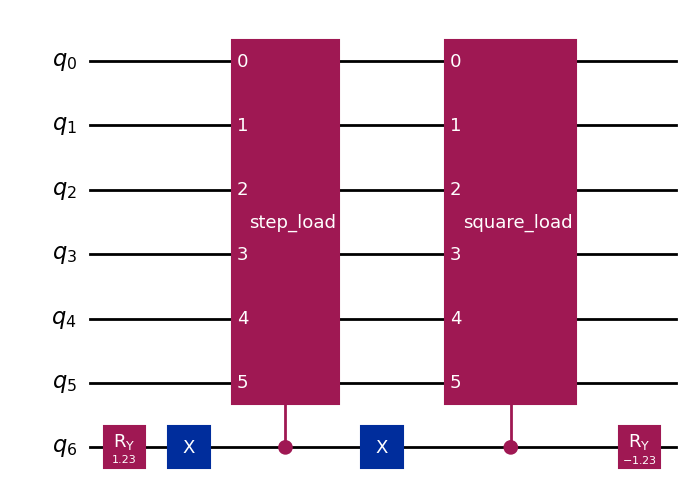

In [20]:
# --- Disjoint STEP + SQUARE ---
circuit, info = encode(
    LCU([(2.0, STEP(k_s=16, c=1.0)),
         (1.0, SQUARE(k1=16, k2=32, c=1.0))]),
    N=N)
print(info)
print(f'Success probability: {info.success_probability:.4f}')
circuit.draw('mpl')


In [21]:
# --- Overlapping components (UserWarning expected) ---
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    circuit, info = encode(
        LCU([(1.0, STEP(k_s=32, c=1.0)),
             (1.0, FOURIER(modes=[(1, 1.0, 0)]))]),
        N=N)
    if w:
        print(f'Warning: {w[0].message}')
print(info)
print(f'Success probability: {info.success_probability:.4f}')


PyEncode  v1.0.0
  Vector type : LCU
  N           : 64  (m = 6 qubits)
  Gate count  : 995
  Complexity  : O(2·m)
  Validated   : no
  Success prob: 0.8181  (post-selection required)
  Parameters  : {'components': ['STEP', 'FOURIER'], 'weights': [1.0, 1.0], 'disjoint': False}
  Circuit code: 23298 chars (info.circuit_code)
Success probability: 0.8181


In [22]:
# --- p vs number of components (equal weight, disjoint) ---
import math
print(f'Theoretical p = 1/r for r equal-weight disjoint components:')
for r in [2, 4, 8]:
    step = N // r
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        intervals = [(1.0, SQUARE(k1=i*step, k2=(i+1)*step, c=1.0)) for i in range(r)]
        _, info_r = encode(LCU(intervals), N=N)
    p_theory = 1/r
    print(f'  r={r}: p={info_r.success_probability:.4f}  (theory 1/r={p_theory:.4f})')


Theoretical p = 1/r for r equal-weight disjoint components:
  r=2: p=0.5000  (theory 1/r=0.5000)
  r=4: p=0.2500  (theory 1/r=0.2500)
  r=8: p=0.1250  (theory 1/r=0.1250)


### 3.8 Qiskit Fallback — unrecognized pattern

Qiskit fallback: total=120  1q=63  2q=57  (O(2^m))


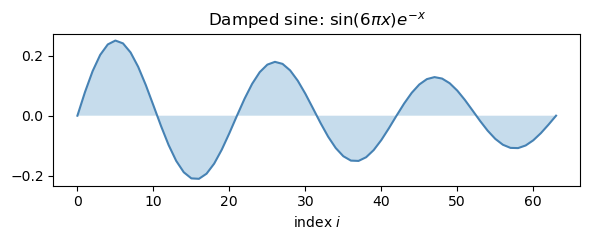

In [23]:
# Damped sine: not in the pattern library -> user falls back explicitly
x = np.linspace(0, 1, N)
f_damped = np.sin(3 * 2*np.pi * x) * np.exp(-x)
f_damped /= np.linalg.norm(f_damped)

qc = QuantumCircuit(int(np.log2(N)))
qc.append(StatePreparation(f_damped.astype(complex)), range(qc.num_qubits))
qc = qc.decompose(reps=DECOMPOSE_REPS)
t = transpile(qc, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
ops = t.count_ops()
total = sum(ops.values())
cx_gates = ops.get("cx", 0)
u_gates  = ops.get("u",  0)
print(f"Qiskit fallback: total={total}  1q={u_gates}  2q={cx_gates}  (O(2^m))")
plot_vector(f_damped, r"Damped sine: $\sin(6\pi x)e^{-x}$", smooth=True)


---
## 4. Gate Count Comparison (Table in Paper)

In [24]:
def pyencode_counts(vobj):
    """Return (raw, 1q, 2q, complexity) for a PyEncode vector object.
    1q/2q come directly from EncodingInfo (populated via validate=True).
    """
    _, info = encode(vobj, N=N, validate=True)
    return info.gate_count, info.gate_count_1q, info.gate_count_2q, info.complexity


cases = [
    ("SPARSE s=1 (k=20)",   SPARSE([(20, 1.0)]),                np.eye(N)[20]),
    ("SPARSE s=2",          SPARSE([(10, 3.0), (50, 4.0)]),     None),
    ("STEP (k_s=4)",        STEP(k_s=4, c=1.0),                np.r_[np.ones(4),  np.zeros(N-4)]),
    ("SQUARE ([8,16))",     SQUARE(k1=8, k2=16, c=1.0),        np.r_[np.zeros(8), np.ones(8), np.zeros(N-16)]),
    ("Walsh (k=1, P=4)",    WALSH(k=1),
     np.array([1.0 if not ((idx>>1)&1) else -1.0 for idx in range(N)])),
    ("FOURIER T=1 n=1",     FOURIER(modes=[(1, 1.0, 0)]),       np.sin(2*np.pi*k/N)),
    ("FOURIER T=1 n=3 phi", FOURIER(modes=[(3, 1.0, np.pi/4)]),
     np.sin(2*np.pi*3*k/N+np.pi/4)),
    ("FOURIER T=2",         FOURIER(modes=[(1, 2.0, 0), (3, 1.0, 0)]),
     2.0*np.sin(2*np.pi*k/N)+np.sin(2*np.pi*3*k/N)),
    ("GEOMETRIC (r=0.95)",  GEOMETRIC(ratio=0.95),
     0.95 ** np.arange(N)),
]


hdr = (f"  {'Pattern':<26} {'Raw':>5} {'Tr':>5} {'1q':>5} {'2q':>5}"
       f"   {'Qsk-Tr':>7} {'Qsk-1q':>7} {'Qsk-2q':>7}  Complexity")
print(hdr)
print("-" * 95)

for desc, vobj, f_ref in cases:
    raw, _1q, _2q, compl = pyencode_counts(vobj)
    transp = (_1q or 0) + (_2q or 0)

    if f_ref is None:
        f_ref = np.zeros(N); f_ref[10] = 3.0; f_ref[50] = 4.0
    qsk_tot, qsk_1q, qsk_2q = qiskit_gate_counts(f_ref)

    _1q_s = str(_1q) if _1q is not None else "n/a"
    _2q_s = str(_2q) if _2q is not None else "n/a"
    print(f"  {desc:<26} {raw:>5} {transp:>5} {_1q_s:>5} {_2q_s:>5}"
          f"   {qsk_tot:>7} {qsk_1q:>7} {qsk_2q:>7}  {compl}")


  Pattern                      Raw    Tr    1q    2q    Qsk-Tr  Qsk-1q  Qsk-2q  Complexity
-----------------------------------------------------------------------------------------------
  SPARSE s=1 (k=20)              2     2     2     0        18      10       8  O(s·m)
  SPARSE s=2                     6     6     4     2        42      23      19  O(s·m)
  STEP (k_s=4)                   2     2     2     0        62      32      30  O(m)
  SQUARE ([8,16))                4     4     4     0        52      28      24  O(m)
  Walsh (k=1, P=4)               7     6     6     0         8       7       1  O(m)
  FOURIER T=1 n=1               11    78    45    33       119      62      57  O(m²)
  FOURIER T=1 n=3 phi           13    80    45    35       119      62      57  O(m²)
  FOURIER T=2                   10    83    48    35       118      61      57  O(m²)
  GEOMETRIC (r=0.95)             6     6     6     0         6       6       0  O(m)


---
## 5. Application Examples
### 5.1 Quantum Chemistry: Fermi-Hubbard PREP

PyEncode  v1.0.0
  Vector type : WALSH
  N           : 16  (m = 4 qubits)
  Gate count  : 5
  Complexity  : O(m)
  Validated   : no
  Gates 1q/2q : 4 / 0
  Depth       : 1
  Success prob: 1.0
  Parameters  : {'k': 3, 'c_pos': 1.0, 'c_neg': 4.0}
  Circuit code: 323 chars (info.circuit_code)


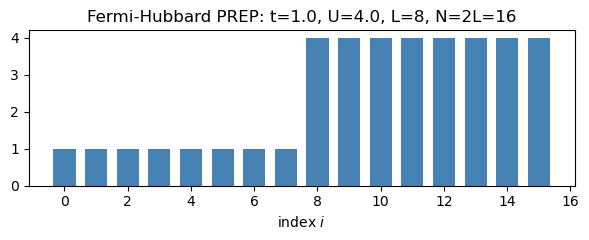

In [25]:
import math
L = 8;  t = 1.0;  U = 4.0

# Equal-block Fermi-Hubbard: L hopping + L interaction, N = 2L
# Generalized Walsh: ancilla-free, m+1 gates
circuit, info = encode(
    WALSH(k=int(math.log2(L)), c_pos=t, c_neg=U),
    N=2*L)
print(info)

f = np.zeros(2*L)
f[:L] = t; f[L:] = U
plot_vector(f, f"Fermi-Hubbard PREP: t={t}, U={U}, L={L}, N=2L={2*L}")


### 5.2 Computational Mechanics: 2D Poisson

x-register: 9 gates
y-register: 12 gates
Total: 21 gates for 1024 amplitudes


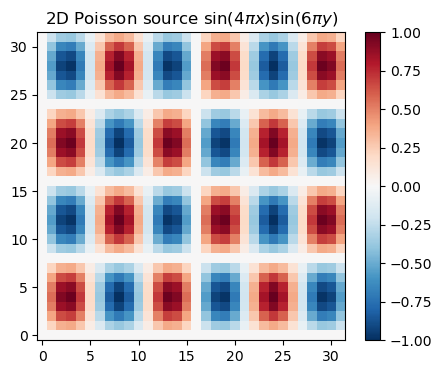

In [26]:
N_grid = 32
k_grid = np.arange(N_grid)

circ_x, info_x = encode(FOURIER(modes=[(2, 1.0, 0)]), N=N_grid)
circ_y, info_y = encode(FOURIER(modes=[(3, 1.0, 0)]), N=N_grid)
circuit = circ_x.tensor(circ_y)

print(f"x-register: {info_x.gate_count} gates")
print(f"y-register: {info_y.gate_count} gates")
print(f"Total: {info_x.gate_count + info_y.gate_count} gates for {N_grid**2} amplitudes")

u = np.sin(2*np.pi*2*k_grid/N_grid)
v = np.sin(2*np.pi*3*k_grid/N_grid)
f_2d = np.outer(u, v)
plt.figure(figsize=(5,4))
plt.imshow(f_2d, cmap="RdBu_r", origin="lower")
plt.colorbar(); plt.title(r"2D Poisson source $\sin(4\pi x)\sin(6\pi y)$")
plt.show()


### 5.3 Quantum Finance: Piecewise-Constant Distribution


PyEncode  v1.0.0
  Vector type : LCU
  N           : 16  (m = 4 qubits)
  Gate count  : 258
  Complexity  : O(4·m)
  Validated   : no
  Success prob: 0.3150  (post-selection required)
  Parameters  : {'components': ['SQUARE', 'SQUARE', 'SQUARE', 'SQUARE'], 'weights': [0.1, 0.4, 0.35, 0.15], 'disjoint': True}
  Circuit code: 7905 chars (info.circuit_code)


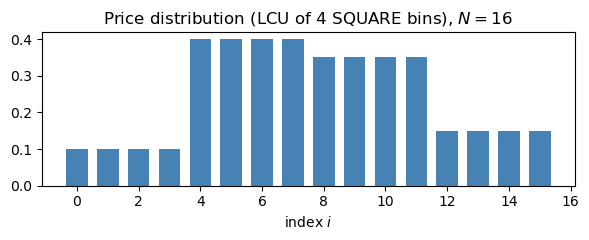

In [27]:
# Piecewise-constant price distribution via LCU of disjoint SQUARE bins
N_fin = 16
circuit, info = encode(
    LCU([(0.10, SQUARE(k1=0,  k2=4,  c=1.0)),
         (0.40, SQUARE(k1=4,  k2=8,  c=1.0)),
         (0.35, SQUARE(k1=8,  k2=12, c=1.0)),
         (0.15, SQUARE(k1=12, k2=16, c=1.0))]),
    N=N_fin)
print(info)

f = np.zeros(N_fin)
f[0:4] = 0.10; f[4:8] = 0.40; f[8:12] = 0.35; f[12:16] = 0.15
plot_vector(f, r"Price distribution (LCU of 4 SQUARE bins), $N=16$")


---
## 6. Circuit Code Output

In [28]:
_, info = encode(FOURIER(modes=[(1, 1.0, 0)]), N=16)
print(info.circuit_code)


# PyEncode — emitted circuit: FOURIER — extracted from synthesized circuit
# m = 4 qubits,  N = 16 nodes
# Edit freely; run as standalone Qiskit code.

from qiskit import QuantumCircuit

import math

m = 4
qc = QuantumCircuit(m, name='fourier')
qc.u(1.5707963268, 0.0000000000, 3.1415926536, 3)
qc.u(3.1415926536, 0.0000000000, 3.1415926536, 3)
qc.cx(3, 0)
qc.u(3.1415926536, 0.0000000000, 3.1415926536, 3)
qc.cx(3, 0)
qc.cx(3, 1)
qc.cx(3, 2)
qc.u(0.0000000000, 0.0000000000, 3.1415926536, 3)
qc.u(1.5707963268, 0.0000000000, 3.1415926536, 3)
qc.u(0.0000000000, 0.0000000000, 0.7853981634, 3)
qc.cx(3, 2)
qc.u(0.0000000000, 0.0000000000, -0.7853981634, 2)
qc.cx(3, 2)
qc.u(0.0000000000, 0.0000000000, 0.7853981634, 2)
qc.u(1.5707963268, 0.0000000000, 3.1415926536, 2)
qc.u(0.0000000000, 0.0000000000, 0.7853981634, 2)
qc.u(0.0000000000, 0.0000000000, 0.3926990817, 3)
qc.cx(3, 1)
qc.u(0.0000000000, 0.0000000000, -0.3926990817, 1)
qc.cx(3, 1)
qc.u(0.0000000000, 0.0000000000, 0.3926990817, 1)
qc.cx(2